# Unit 2 | NLP 04 — Semantic Sentence Embeddings

Bag-of-words treats words as independent symbols. **Sentence embeddings** map text into a continuous vector space where *meaning* determines proximity.

```
"The rocket launched"  →  [0.12, -0.45, 0.87, ...]   ← 384-dim vector
"The spacecraft lifted off"  →  [0.11, -0.43, 0.85, ...]   ← nearby in space
"The stock market fell"  →  [-0.62, 0.31, -0.11, ...]  ← far away
```

This notebook covers:

1. **Why bag-of-words fails for semantics**
2. **Sentence Transformers** — pre-trained models from HuggingFace
3. **Semantic similarity** — cosine distance between embeddings
4. **PCA & t-SNE visualization** — see the embedding space
5. **Nearest-neighbor sanity check** — do similar documents cluster?

**Dataset:** sklearn 20 Newsgroups (subsampled for speed)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('dark_background')

In [2]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
CATEGORIES   = ['sci.space', 'comp.graphics', 'rec.sport.hockey', 'talk.religion.misc']
RANDOM_STATE = 42
MODEL_NAME   = 'all-MiniLM-L6-v2'   # fast, 384-dim — good for demos
DOCS_PER_CAT = 150                   # subsample to keep encoding fast
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
data = fetch_20newsgroups(
    subset='train', categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'), random_state=RANDOM_STATE
)

# Subsample: DOCS_PER_CAT documents per category
np.random.seed(RANDOM_STATE)
keep_idx = []
for cat_idx in range(len(CATEGORIES)):
    idx = np.where(data.target == cat_idx)[0]
    keep_idx.extend(np.random.choice(idx, size=min(DOCS_PER_CAT, len(idx)), replace=False))

docs   = [data.data[i][:1000] for i in keep_idx]   # cap at 1000 chars/doc
labels = data.target[keep_idx]
label_names = [data.target_names[l] for l in labels]

print(f"Documents to embed: {len(docs)}")
print(f"Category breakdown: { {data.target_names[i]: int((labels==i).sum()) for i in range(len(CATEGORIES))} }")

Documents to embed: 600
Category breakdown: {'comp.graphics': 150, 'rec.sport.hockey': 150, 'sci.space': 150, 'talk.religion.misc': 150}


## 1. Why Bag-of-Words Fails for Semantics

Consider these two sentences:

| Sentence | CountVec overlap |
|---|---|
| "The rocket launched from the pad." | — |
| "The spacecraft lifted off from the platform." | 2 words (`the`, `from`) |

These sentences are **semantically identical** but share almost no vocabulary. CountVectorizer would treat them as very different documents.

Sentence embeddings solve this by learning a shared representation where *meaning* determines distance, not just word overlap.

## 2. Encoding Documents with SentenceTransformer

In [4]:
# Load the pre-trained model (downloads once, cached after)
model = SentenceTransformer(MODEL_NAME)
print(f"Model: {MODEL_NAME}")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")
print()

# Encode — show_progress_bar gives feedback on longer batches
embeddings = model.encode(docs, show_progress_bar=True, batch_size=64)

print(f"\nEmbedding matrix shape: {embeddings.shape}")
print(f"Each document → a {embeddings.shape[1]}-dimensional vector")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: all-MiniLM-L6-v2
Embedding dimension: 384



Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Embedding matrix shape: (600, 384)
Each document → a 384-dimensional vector


## 3. Semantic Similarity

We can measure how similar two documents are by computing the **cosine similarity** of their embeddings:

$$\text{cosine}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}$$

Values range from −1 (opposite meaning) to +1 (identical meaning).

In [5]:
# Pick a query document and find most/least similar
query_idx  = 0
query_doc  = docs[query_idx]
query_cat  = label_names[query_idx]

print(f"Query ({query_cat}):")
print(query_doc[:300])
print()

sim = cosine_similarity([embeddings[query_idx]], embeddings)[0]

top5_idx = sim.argsort()[::-1][1:6]    # skip self (index 0)
bot5_idx = sim.argsort()[:5]

print("Top 5 MOST similar documents:")
for rank, i in enumerate(top5_idx, 1):
    print(f"  [{rank}] sim={sim[i]:.3f}  cat={label_names[i]}")
    print(f"      {docs[i][:120]}\n")

print("\nTop 5 LEAST similar documents:")
for rank, i in enumerate(bot5_idx, 1):
    print(f"  [{rank}] sim={sim[i]:.3f}  cat={label_names[i]}")
    print(f"      {docs[i][:120]}\n")

Query (comp.graphics):
The real problem w/ the Stealth from what I've heard is that Diamond won't
tell anyone how to program their proprietary clock stuff, so X under Linux
and 386BSD won't run....


Top 5 MOST similar documents:
  [1] sim=0.367  cat=comp.graphics
      Visual Numerics Inc. (formerly IMSL and Precision Visuals) is in the
process of securing sites for beta testing X Expone

  [2] sim=0.352  cat=comp.graphics
      I would like to program Tseng ET4000 to nonstandard 1024x768 mode by
switching to standard 1024x768 mode using BIOS and 

  [3] sim=0.336  cat=comp.graphics
      
The RS6000 compiler is so forgiving, I think that if you mixed COBOL & pascal
the C compiler still wouldn't complain. :

  [4] sim=0.329  cat=comp.graphics
      Organization: "A World of Information at your Fingertips"
Keywords: 



Craig,

You should still consider the Targa+. I 

  [5] sim=0.328  cat=comp.graphics
      : There is a new version of the RTrace ray-tracing package (8.2.0) at
: aster

## 4. Visualization

**Principal Component Analysis (PCA)** linearly projects high-dimensional embeddings into 2D. It preserves global variance — clusters that are far apart in 384 dimensions stay far apart in 2D.

**t-SNE** is a non-linear dimensionality reduction algorithm that prioritizes preserving *local* structure — points that are close in high-dimensional space end up close in 2D. It often produces cleaner clusters than PCA for embeddings, but:

- It is slower
- The global layout (which cluster is near which) is not meaningful
- Results vary with `perplexity`

Variance explained by PC1: 6.1%
Variance explained by PC2: 4.7%
Total: 10.7%


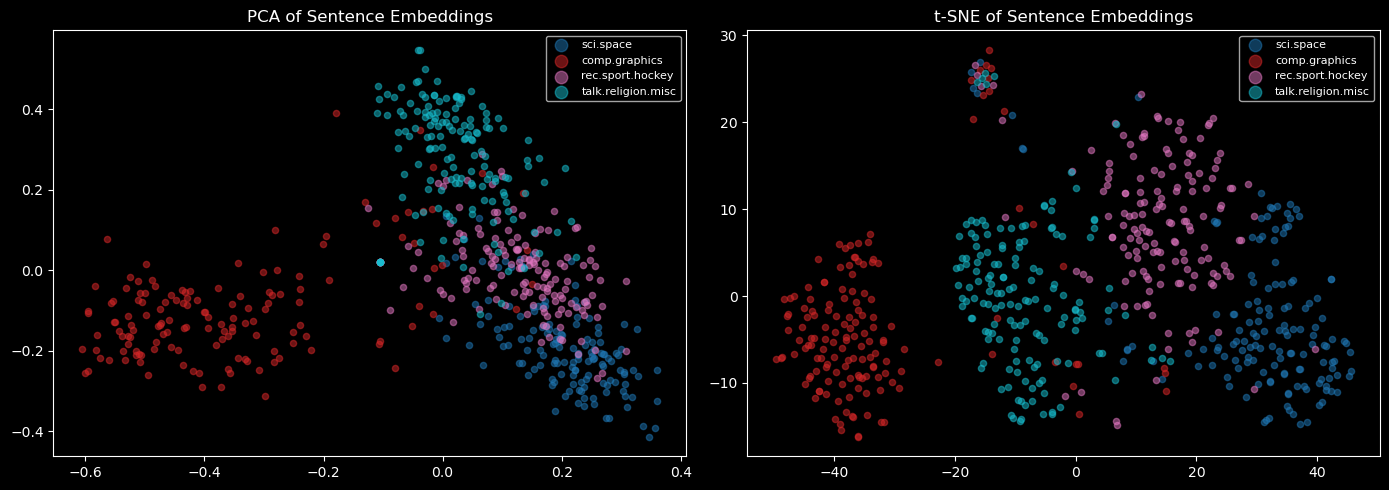

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
emb_2d_pca = pca.fit_transform(embeddings)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total: {pca.explained_variance_ratio_.sum():.1%}")

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
emb_2d_tsne = tsne.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ['PCA', 't-SNE']
coords = [emb_2d_pca, emb_2d_tsne]

for ax, title, xy in zip(axes, titles, coords):
    for cat_idx, cat in enumerate(CATEGORIES):
        mask = labels == cat_idx
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   label=cat, alpha=0.5, s=20, color=cmap(cat_idx))
    ax.set_title(f'{title} of Sentence Embeddings')
    ax.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

### Compare embeddings with sklearn vectorization

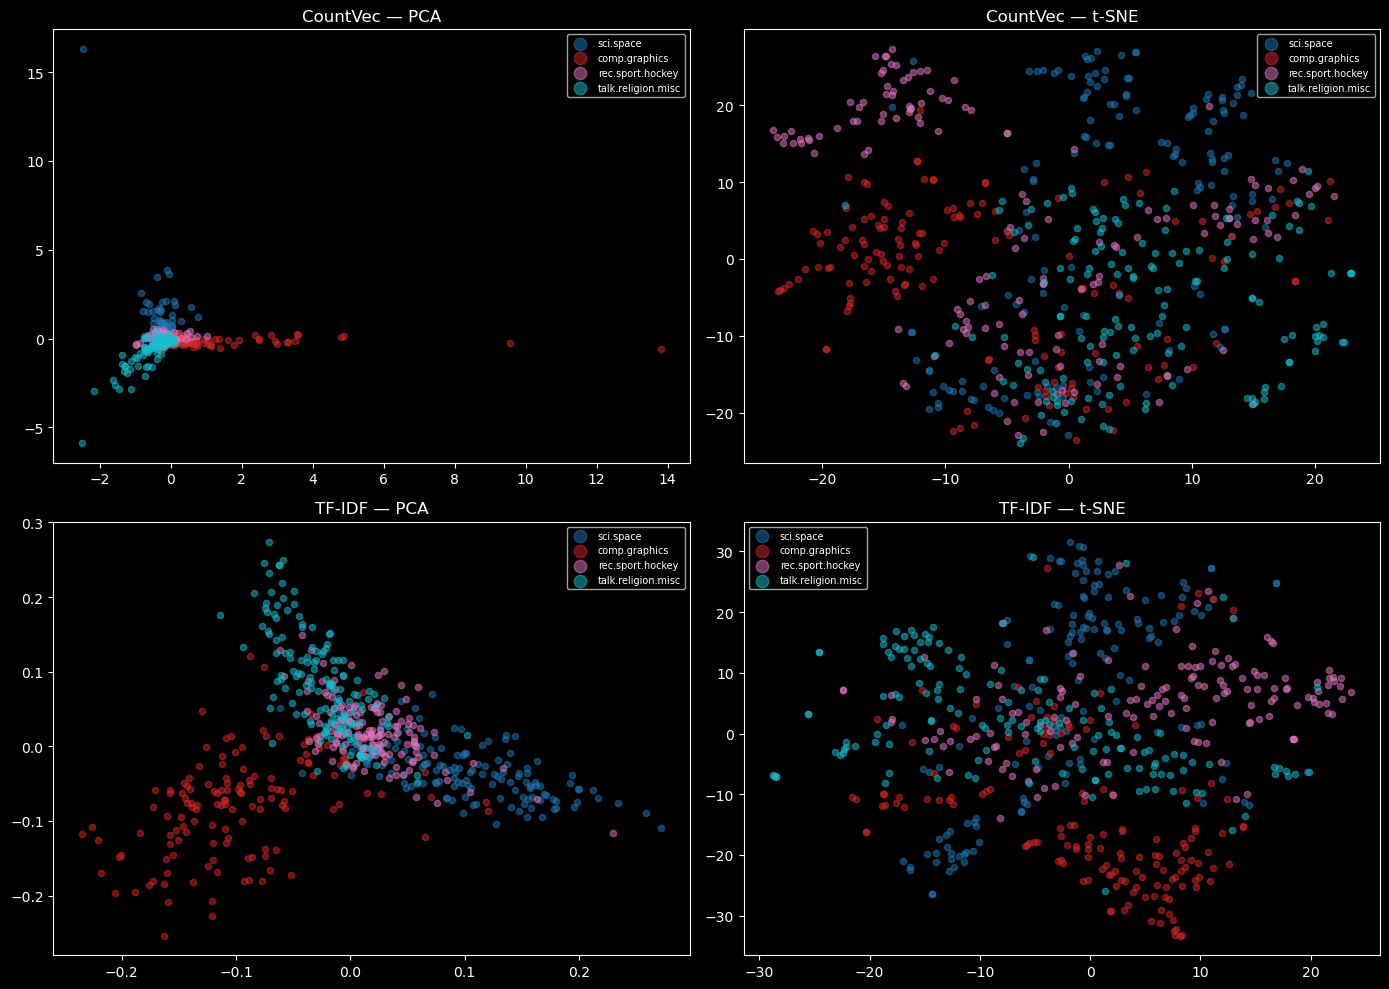

In [25]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.base import clone

viz_vectorizers = {
    'CountVec': CountVectorizer(max_features=5000, stop_words='english', ngram_range=(1,1), min_df=2),
    'TF-IDF':   TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,1), min_df=2, sublinear_tf=True),
}

cmap = plt.cm.get_cmap('tab10', len(CATEGORIES))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (vec_name, vec) in enumerate(viz_vectorizers.items()):
    X = vec.fit_transform(docs).toarray()

    pca  = PCA(n_components=20, random_state=RANDOM_STATE)
    X_20 = pca.fit_transform(X)
    X_pca = X_20[:, :2]  # first 2 PCs for plotting

    tsne  = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
    X_tsne = tsne.fit_transform(X_20)

    for col, (title, xy) in enumerate(zip(['PCA', 't-SNE'], [X_pca, X_tsne])):
        ax = axes[row, col]
        for cat_idx, cat in enumerate(CATEGORIES):
            mask = labels == cat_idx
            ax.scatter(xy[mask, 0], xy[mask, 1],
                   label=cat, alpha=0.5, s=20, color=cmap(cat_idx))
        ax.set_title(f'{vec_name} — {title}')
        ax.legend(markerscale=2, fontsize=7)

plt.tight_layout()
plt.show()

## Summary

| | Bag-of-Words | Sentence Embeddings |
|---|---|---|
| Representation | Sparse, high-dim (vocab size) | Dense, fixed-dim (e.g. 384) |
| Captures synonyms | No | Yes |
| Captures word order | No | Partially |
| Training data needed | No (fit on corpus) | No (pre-trained) |
| Interpretability | High (features are words) | Low (features are latent dims) |
| Speed | Fast | Slower (transformer inference) |

**Next →** Notebook 5 runs a head-to-head comparison of classical and semantic approaches on the same classification task.